In [1]:
# Import all necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (accuracy_score, classification_report, 
                             confusion_matrix, ConfusionMatrixDisplay)
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
# Load the Wine dataset
wine = datasets.load_wine()

# Create a DataFrame for exploration
df = pd.DataFrame(wine.data, columns=wine.feature_names)
df['target'] = wine.target
df['target_name'] = df['target'].map({0: 'Class 0', 1: 'Class 1', 2: 'Class 2'})

print("Dataset Shape:", df.shape)
print("\nFeature Names:")
for i, name in enumerate(wine.feature_names):
    print(f"  {i+1}. {name}")
print(f"\nNumber of classes: {len(wine.target_names)}")
print(f"\nClass distribution:")
print(df['target_name'].value_counts())
print(f"\nFirst 5 rows:")
df.head()

Dataset Shape: (178, 15)

Feature Names:
  1. alcohol
  2. malic_acid
  3. ash
  4. alcalinity_of_ash
  5. magnesium
  6. total_phenols
  7. flavanoids
  8. nonflavanoid_phenols
  9. proanthocyanins
  10. color_intensity
  11. hue
  12. od280/od315_of_diluted_wines
  13. proline

Number of classes: 3

Class distribution:
target_name
Class 1    71
Class 0    59
Class 2    48
Name: count, dtype: int64

First 5 rows:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target,target_name
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0,Class 0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0,Class 0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0,Class 0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0,Class 0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0,Class 0


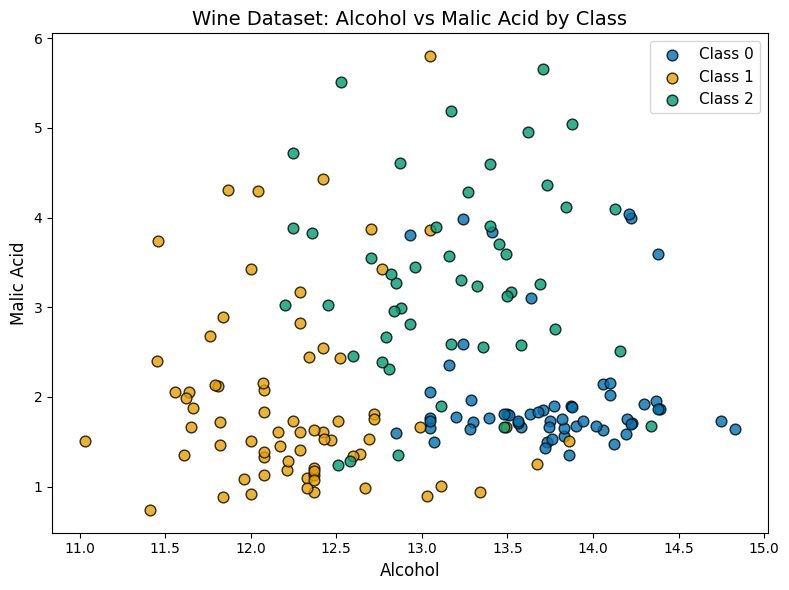

Figure 1: Scatter plot showing the two features used in this tutorial.
The three classes overlap in some regions, making this a good test for different SVM kernels.


In [3]:
# Visualise the two features we will use
# Using colourblind-friendly palette
cb_palette = ['#0072B2', '#E69F00', '#009E73']

fig, ax = plt.subplots(1, 1, figsize=(8, 6))

for idx, class_name in enumerate(['Class 0', 'Class 1', 'Class 2']):
    subset = df[df['target_name'] == class_name]
    ax.scatter(subset['alcohol'], subset['malic_acid'], 
              c=cb_palette[idx], label=class_name, 
              edgecolors='black', s=60, alpha=0.8)

ax.set_xlabel('Alcohol', fontsize=12)
ax.set_ylabel('Malic Acid', fontsize=12)
ax.set_title('Wine Dataset: Alcohol vs Malic Acid by Class', fontsize=14)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('dataset_overview.png', dpi=150, bbox_inches='tight')
plt.show()

print("Figure 1: Scatter plot showing the two features used in this tutorial.")
print("The three classes overlap in some regions, making this a good test for different SVM kernels.")

In [4]:
# Prepare data for SVM
X = wine.data[:, :2]  # Alcohol and Malic Acid
y = wine.target

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Standardise features (important for SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set size: {X_train_scaled.shape[0]} samples")
print(f"Test set size: {X_test_scaled.shape[0]} samples")
print(f"Features used: {wine.feature_names[0]}, {wine.feature_names[1]}")

Training set size: 124 samples
Test set size: 54 samples
Features used: alcohol, malic_acid


In [5]:
# Function to plot decision boundaries
def plot_decision_boundary(ax, clf, X_train, y_train, title, cb_palette):
    """
    Plots the decision boundary of a trained classifier.
    Uses colourblind-friendly colours.
    """
    from matplotlib.colors import ListedColormap
    
    h = 0.02
    x_min, x_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
    y_min, y_max = X_train[:, 1].min() - 1, X_train[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                          np.arange(y_min, y_max, h))
    
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    cmap_light = ListedColormap(['#A6CEE3', '#FDBF6F', '#B2DF8A'])
    
    ax.contourf(xx, yy, Z, alpha=0.3, cmap=cmap_light)
    ax.contour(xx, yy, Z, colors='gray', linewidths=0.5)
    
    for idx in range(3):
        mask = y_train == idx
        ax.scatter(X_train[mask, 0], X_train[mask, 1],
                  c=cb_palette[idx], label=f'Class {idx}',
                  edgecolors='black', s=50, alpha=0.8)
    
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Alcohol (scaled)', fontsize=10)
    ax.set_ylabel('Malic Acid (scaled)', fontsize=10)

print("Decision boundary plotting function defined.")

Decision boundary plotting function defined.


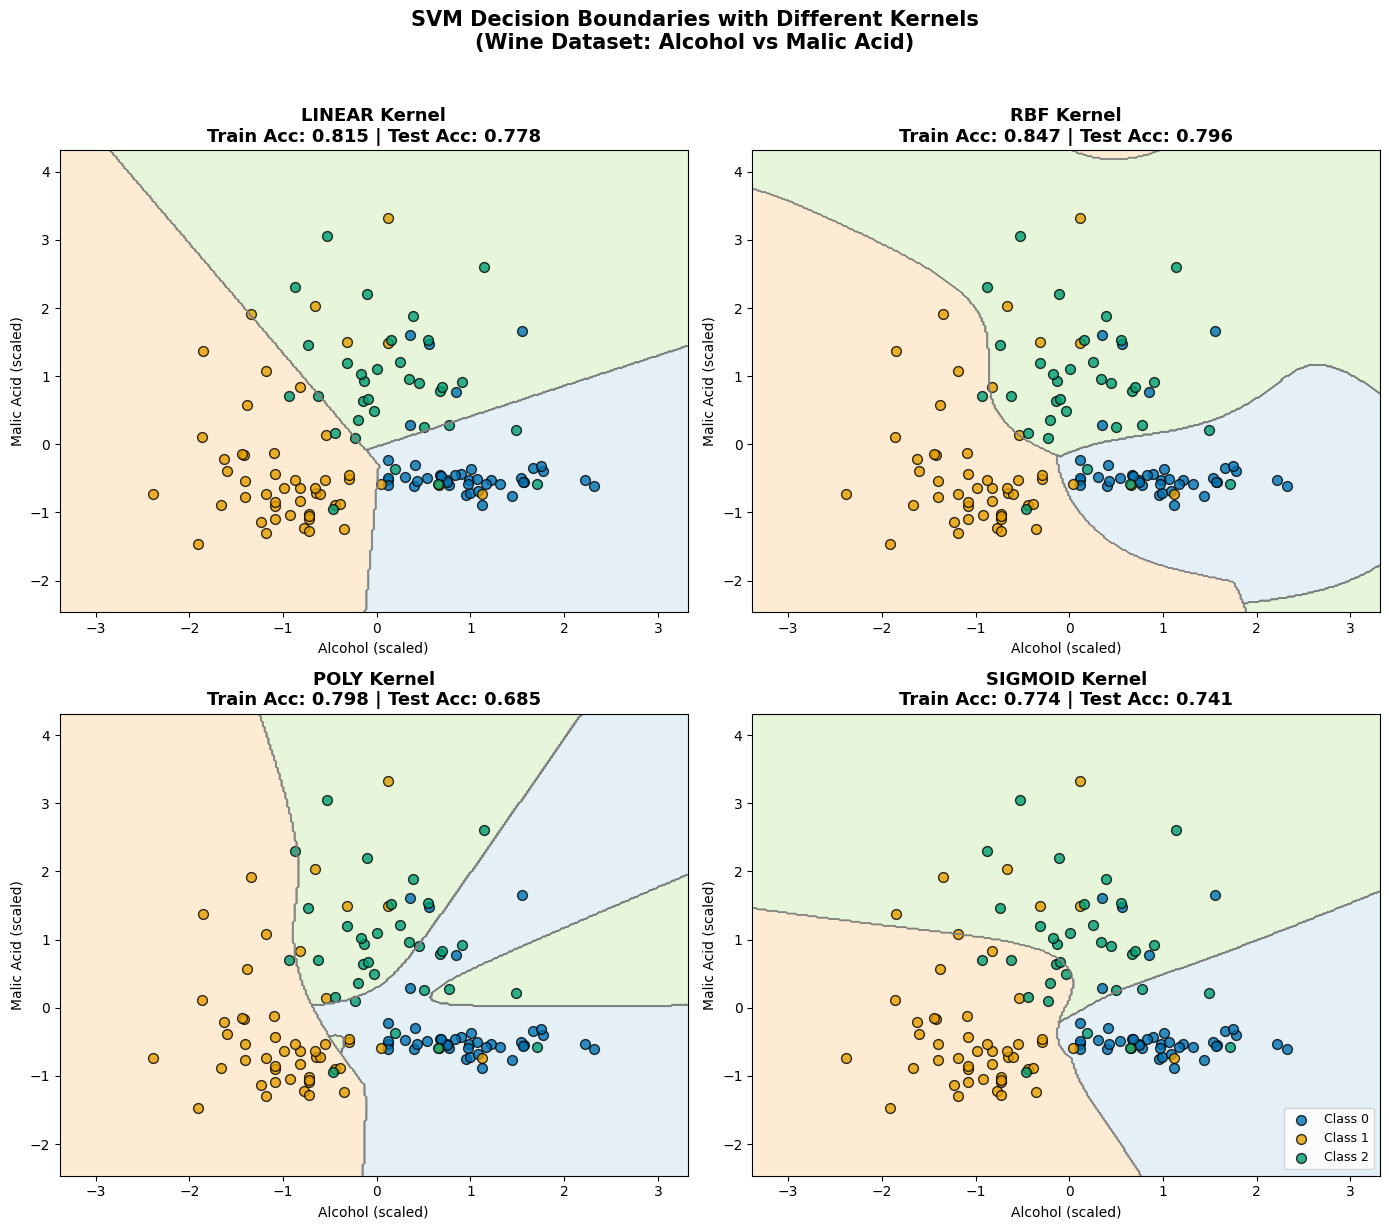


Figure 2: Decision boundaries for four different SVM kernels.
Each kernel creates a fundamentally different separation pattern.


In [6]:
# Train SVM with each kernel and plot decision boundaries
kernels = ['linear', 'rbf', 'poly', 'sigmoid']
kernel_params = {
    'linear':  {'C': 1.0},
    'rbf':     {'C': 1.0, 'gamma': 'scale'},
    'poly':    {'C': 1.0, 'gamma': 'scale', 'degree': 3},
    'sigmoid': {'C': 1.0, 'gamma': 'scale'}
}

cb_palette = ['#0072B2', '#E69F00', '#009E73']

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.ravel()

results = {}

for idx, kernel in enumerate(kernels):
    clf = SVC(kernel=kernel, **kernel_params[kernel], random_state=42)
    clf.fit(X_train_scaled, y_train)
    
    train_acc = clf.score(X_train_scaled, y_train)
    test_acc = clf.score(X_test_scaled, y_test)
    
    results[kernel] = {
        'model': clf,
        'train_accuracy': train_acc,
        'test_accuracy': test_acc,
        'n_support_vectors': clf.n_support_.sum()
    }
    
    title = f'{kernel.upper()} Kernel\nTrain Acc: {train_acc:.3f} | Test Acc: {test_acc:.3f}'
    plot_decision_boundary(axes[idx], clf, X_train_scaled, y_train, title, cb_palette)

axes[3].legend(loc='lower right', fontsize=9)

plt.suptitle('SVM Decision Boundaries with Different Kernels\n(Wine Dataset: Alcohol vs Malic Acid)', 
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('kernel_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nFigure 2: Decision boundaries for four different SVM kernels.")
print("Each kernel creates a fundamentally different separation pattern.")

In [7]:
# Create comparison table
comparison_data = []
for kernel in kernels:
    r = results[kernel]
    clf = SVC(kernel=kernel, **kernel_params[kernel], random_state=42)
    cv_scores = cross_val_score(clf, X_train_scaled, y_train, cv=5, scoring='accuracy')
    
    comparison_data.append({
        'Kernel': kernel.upper(),
        'Train Accuracy': f"{r['train_accuracy']:.4f}",
        'Test Accuracy': f"{r['test_accuracy']:.4f}",
        'CV Mean Accuracy': f"{cv_scores.mean():.4f}",
        'CV Std': f"{cv_scores.std():.4f}",
        'Support Vectors': r['n_support_vectors']
    })

comparison_df = pd.DataFrame(comparison_data)
print("Table 1: Quantitative comparison of SVM kernels")
print("=" * 85)
print(comparison_df.to_string(index=False))
print("=" * 85)

Table 1: Quantitative comparison of SVM kernels
 Kernel Train Accuracy Test Accuracy CV Mean Accuracy CV Std  Support Vectors
 LINEAR         0.8145        0.7778           0.8230 0.0892               58
    RBF         0.8468        0.7963           0.8067 0.0458               63
   POLY         0.7984        0.6852           0.7020 0.0922               83
SIGMOID         0.7742        0.7407           0.7827 0.0587               57


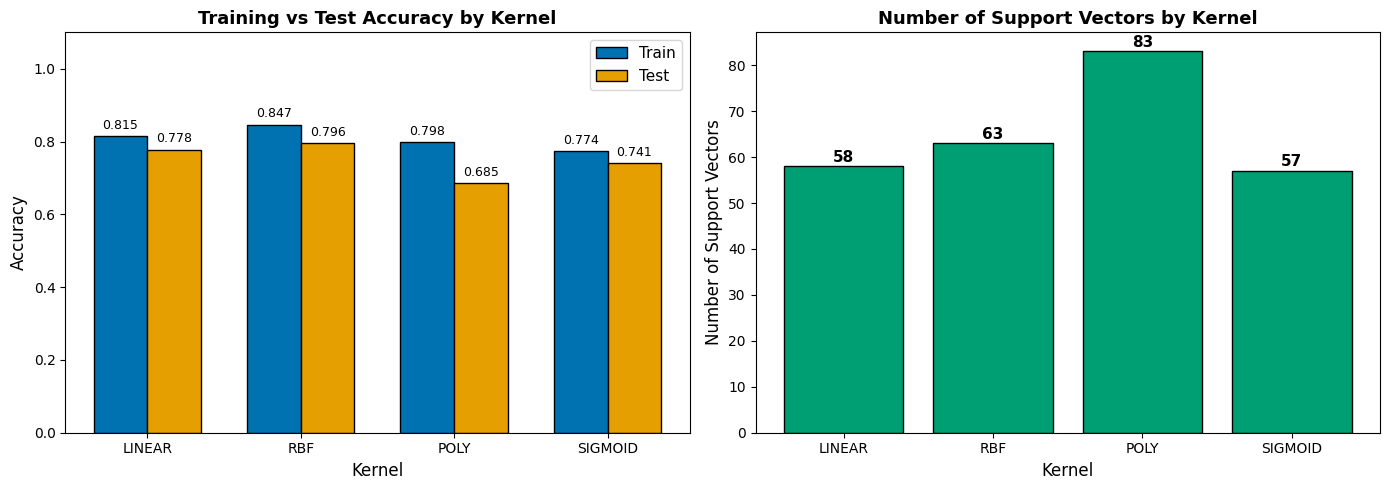


Figure 3: Left - Accuracy comparison. Right - Support vector counts.


In [8]:
# Bar chart comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

kernel_names = [k.upper() for k in kernels]
train_accs = [results[k]['train_accuracy'] for k in kernels]
test_accs = [results[k]['test_accuracy'] for k in kernels]

x = np.arange(len(kernel_names))
width = 0.35

axes[0].bar(x - width/2, train_accs, width, label='Train', color='#0072B2', edgecolor='black')
axes[0].bar(x + width/2, test_accs, width, label='Test', color='#E69F00', edgecolor='black')
axes[0].set_xlabel('Kernel', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_title('Training vs Test Accuracy by Kernel', fontsize=13, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(kernel_names)
axes[0].legend(fontsize=11)
axes[0].set_ylim(0, 1.1)

for i, (tr, te) in enumerate(zip(train_accs, test_accs)):
    axes[0].text(i - width/2, tr + 0.02, f'{tr:.3f}', ha='center', fontsize=9)
    axes[0].text(i + width/2, te + 0.02, f'{te:.3f}', ha='center', fontsize=9)

sv_counts = [results[k]['n_support_vectors'] for k in kernels]
bars = axes[1].bar(kernel_names, sv_counts, color='#009E73', edgecolor='black')
axes[1].set_xlabel('Kernel', fontsize=12)
axes[1].set_ylabel('Number of Support Vectors', fontsize=12)
axes[1].set_title('Number of Support Vectors by Kernel', fontsize=13, fontweight='bold')

for bar, count in zip(bars, sv_counts):
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
                str(count), ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('accuracy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nFigure 3: Left - Accuracy comparison. Right - Support vector counts.")

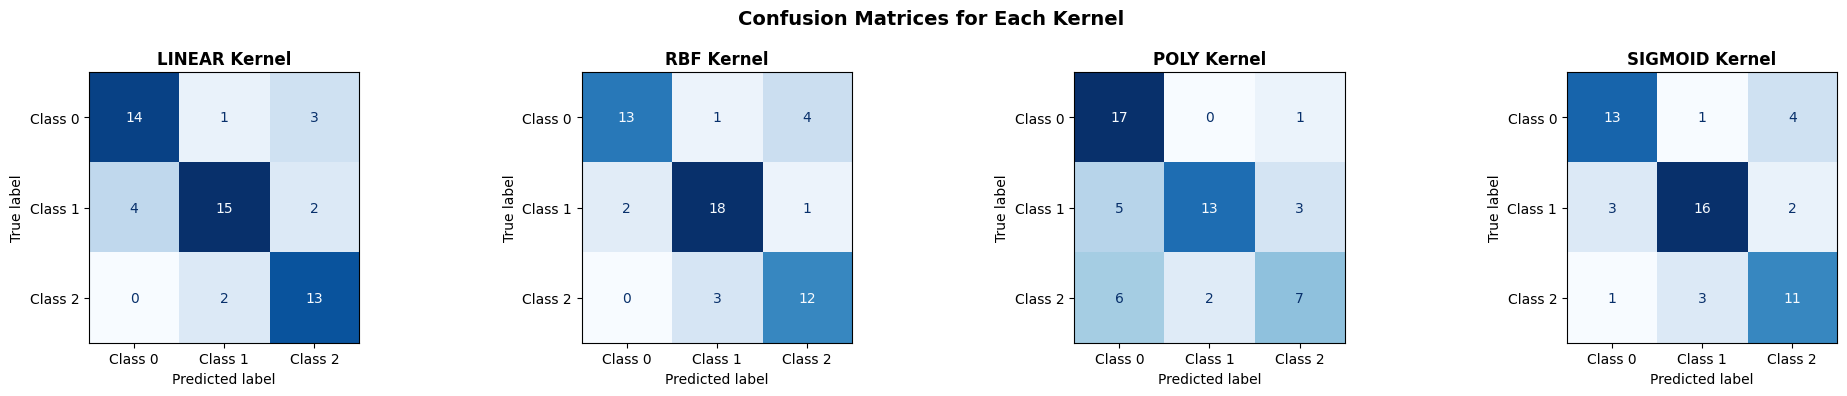


Figure 4: Confusion matrices showing per-class prediction accuracy.


In [9]:
# Confusion matrices
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

for idx, kernel in enumerate(kernels):
    clf = results[kernel]['model']
    y_pred = clf.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)
    
    disp = ConfusionMatrixDisplay(cm, display_labels=['Class 0', 'Class 1', 'Class 2'])
    disp.plot(ax=axes[idx], cmap='Blues', colorbar=False)
    axes[idx].set_title(f'{kernel.upper()} Kernel', fontsize=12, fontweight='bold')

plt.suptitle('Confusion Matrices for Each Kernel', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nFigure 4: Confusion matrices showing per-class prediction accuracy.")

In [10]:
# Classification reports
for kernel in kernels:
    clf = results[kernel]['model']
    y_pred = clf.predict(X_test_scaled)
    print(f"\n{'='*60}")
    print(f"Classification Report: {kernel.upper()} Kernel")
    print(f"{'='*60}")
    print(classification_report(y_test, y_pred, target_names=['Class 0', 'Class 1', 'Class 2']))


Classification Report: LINEAR Kernel
              precision    recall  f1-score   support

     Class 0       0.78      0.78      0.78        18
     Class 1       0.83      0.71      0.77        21
     Class 2       0.72      0.87      0.79        15

    accuracy                           0.78        54
   macro avg       0.78      0.79      0.78        54
weighted avg       0.78      0.78      0.78        54


Classification Report: RBF Kernel
              precision    recall  f1-score   support

     Class 0       0.87      0.72      0.79        18
     Class 1       0.82      0.86      0.84        21
     Class 2       0.71      0.80      0.75        15

    accuracy                           0.80        54
   macro avg       0.80      0.79      0.79        54
weighted avg       0.80      0.80      0.80        54


Classification Report: POLY Kernel
              precision    recall  f1-score   support

     Class 0       0.61      0.94      0.74        18
     Class 1       0

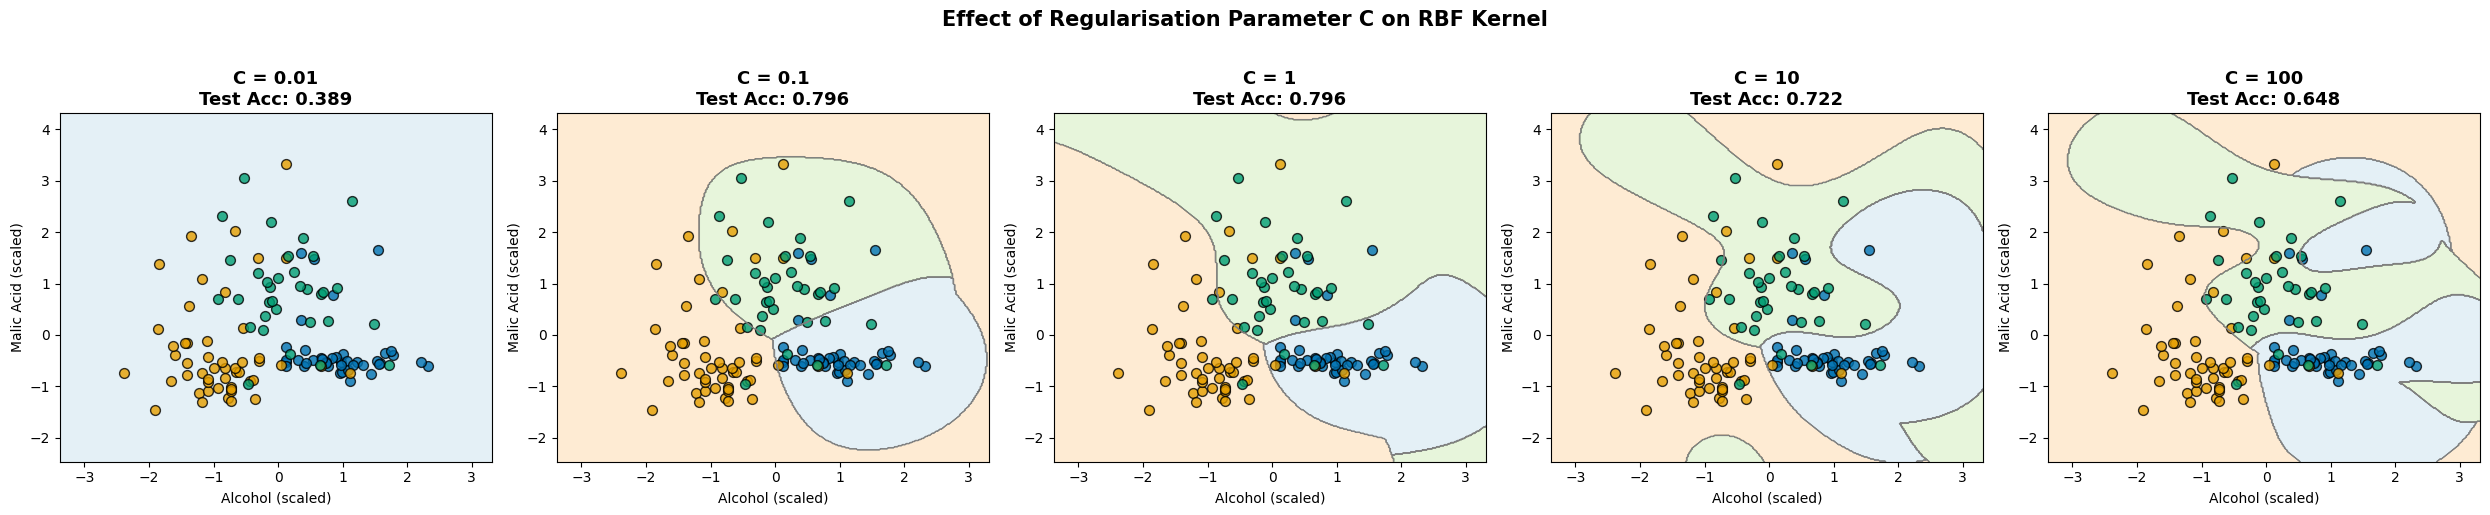


Figure 5: As C increases, the decision boundary becomes more complex.
Very high C values can lead to overfitting.


In [11]:
# Effect of C parameter
C_values = [0.01, 0.1, 1, 10, 100]
cb_palette = ['#0072B2', '#E69F00', '#009E73']

fig, axes = plt.subplots(1, 5, figsize=(25, 5))

for idx, C in enumerate(C_values):
    clf = SVC(kernel='rbf', C=C, gamma='scale', random_state=42)
    clf.fit(X_train_scaled, y_train)
    test_acc = clf.score(X_test_scaled, y_test)
    
    title = f'C = {C}\nTest Acc: {test_acc:.3f}'
    plot_decision_boundary(axes[idx], clf, X_train_scaled, y_train, title, cb_palette)

plt.suptitle('Effect of Regularisation Parameter C on RBF Kernel', 
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('c_parameter_effect.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nFigure 5: As C increases, the decision boundary becomes more complex.")
print("Very high C values can lead to overfitting.")

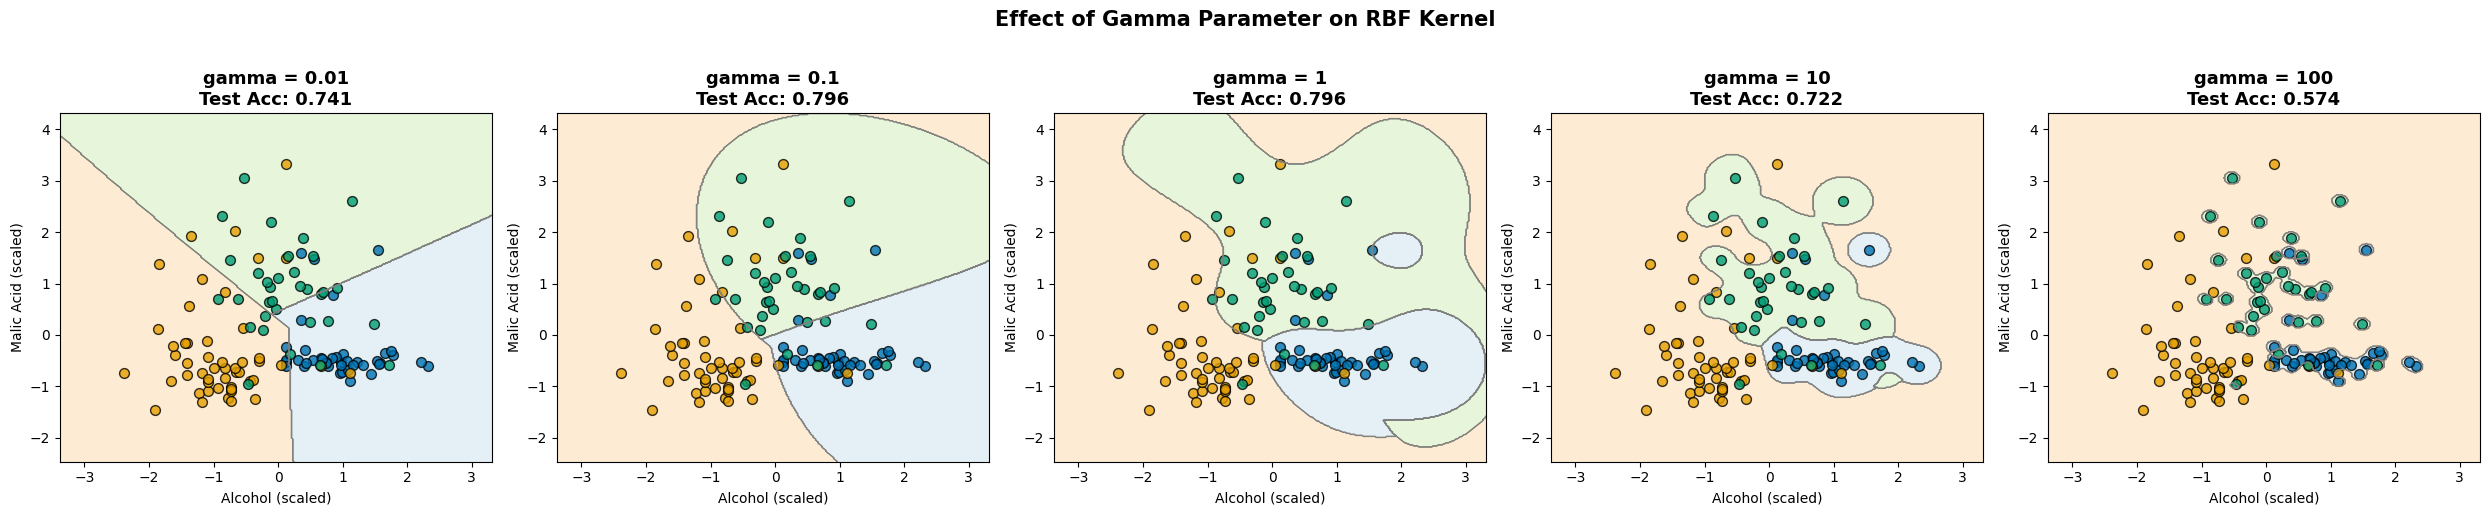


Figure 6: Low gamma = smooth boundaries. High gamma = overfitting.


In [12]:
# Effect of gamma
gamma_values = [0.01, 0.1, 1, 10, 100]
cb_palette = ['#0072B2', '#E69F00', '#009E73']

fig, axes = plt.subplots(1, 5, figsize=(25, 5))

for idx, gamma in enumerate(gamma_values):
    clf = SVC(kernel='rbf', C=1.0, gamma=gamma, random_state=42)
    clf.fit(X_train_scaled, y_train)
    test_acc = clf.score(X_test_scaled, y_test)
    
    title = f'gamma = {gamma}\nTest Acc: {test_acc:.3f}'
    plot_decision_boundary(axes[idx], clf, X_train_scaled, y_train, title, cb_palette)

plt.suptitle('Effect of Gamma Parameter on RBF Kernel', 
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('gamma_effect.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nFigure 6: Low gamma = smooth boundaries. High gamma = overfitting.")

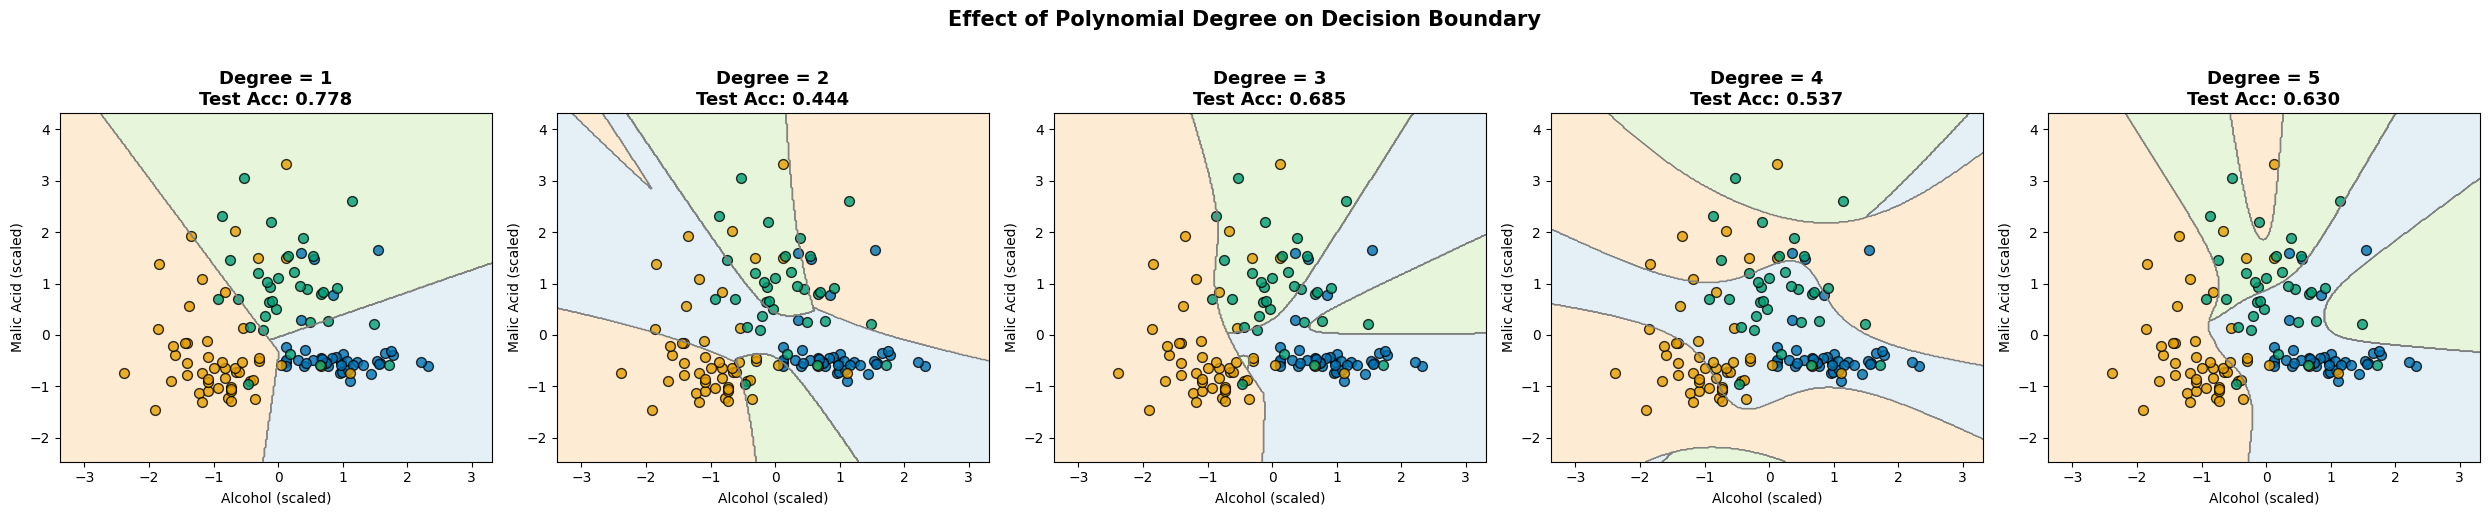


Figure 7: Degree 2-3 often gives the best balance between complexity and generalisation.


In [13]:
# Effect of polynomial degree
degrees = [1, 2, 3, 4, 5]
cb_palette = ['#0072B2', '#E69F00', '#009E73']

fig, axes = plt.subplots(1, 5, figsize=(25, 5))

for idx, degree in enumerate(degrees):
    clf = SVC(kernel='poly', C=1.0, degree=degree, gamma='scale', random_state=42)
    clf.fit(X_train_scaled, y_train)
    test_acc = clf.score(X_test_scaled, y_test)
    
    title = f'Degree = {degree}\nTest Acc: {test_acc:.3f}'
    plot_decision_boundary(axes[idx], clf, X_train_scaled, y_train, title, cb_palette)

plt.suptitle('Effect of Polynomial Degree on Decision Boundary', 
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('degree_effect.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nFigure 7: Degree 2-3 often gives the best balance between complexity and generalisation.")

In [15]:
# ============================================================
# SUMMARY OF FINDINGS
# ============================================================
print("=" * 70)
print("SUMMARY: SVM Kernel Comparison Results")
print("=" * 70)
print(f"\n{'Kernel':<12} {'Train Acc':<12} {'Test Acc':<12} {'Support Vectors':<18}")
print("-" * 54)
for kernel in kernels:
    r = results[kernel]
    print(f"{kernel.upper():<12} {r['train_accuracy']:<12.4f} {r['test_accuracy']:<12.4f} {r['n_support_vectors']:<18}")

print("\n" + "=" * 70)
print("KEY TAKEAWAYS:")
print("=" * 70)
print("1. RBF kernel — best general-purpose choice")
print("2. Linear kernel — fastest, best for high-dimensional data")
print("3. Polynomial kernel — tunable complexity via degree parameter")
print("4. Sigmoid kernel — generally not recommended")
print("5. Always standardise features before using SVM")
print("6. Tune C and gamma using cross-validation")
print("=" * 70)


SUMMARY: SVM Kernel Comparison Results

Kernel       Train Acc    Test Acc     Support Vectors   
------------------------------------------------------
LINEAR       0.8145       0.7778       58                
RBF          0.8468       0.7963       63                
POLY         0.7984       0.6852       83                
SIGMOID      0.7742       0.7407       57                

KEY TAKEAWAYS:
1. RBF kernel — best general-purpose choice
2. Linear kernel — fastest, best for high-dimensional data
3. Polynomial kernel — tunable complexity via degree parameter
4. Sigmoid kernel — generally not recommended
5. Always standardise features before using SVM
6. Tune C and gamma using cross-validation
